# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Herlan Jaelani
- Email: herlanjaelani1507@gmail.com
- Id Dicoding: herlanjae

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os


### Menyiapkan data yang akan diguankan

## Data Understanding

   Marital_status  Application_mode  Application_order  Course  \
0               1                17                  5     171   
1               1                15                  1    9254   
2               1                 1                  5    9070   
3               1                17                  2    9773   
4               2                39                  1    8014   

   Daytime_evening_attendance  Previous_qualification  \
0                           1                       1   
1                           1                       1   
2                           1                       1   
3                           1                       1   
4                           0                       1   

   Previous_qualification_grade  Nacionality  Mothers_qualification  \
0                         122.0            1                     19   
1                         160.0            1                      1   
2                         122.0            1   

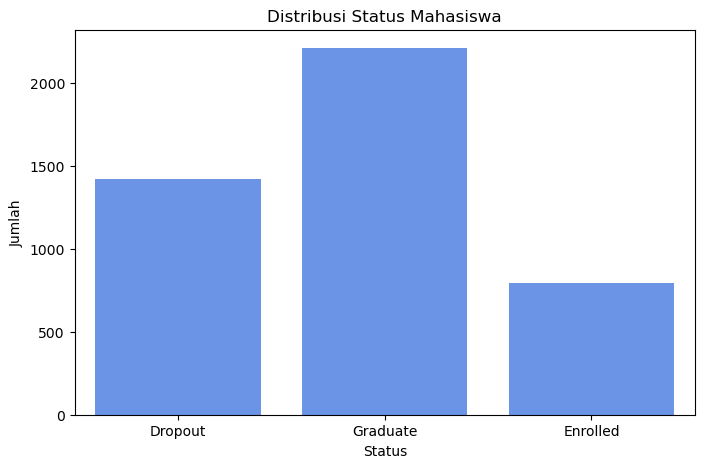

In [2]:
df = pd.read_csv("data/data.csv", encoding="windows-1252", delimiter=";")
df.rename(columns={'ï»¿Marital_status': 'Marital_status'}, inplace=True)
print(df.head())

print("\n--- Info Dataset ---")
print(df.info())

print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum())

print("\n--- Cek Distribusi Target ---")
target_column = "Status"

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_column)
plt.title("Distribusi Status Mahasiswa")
plt.xlabel("Status")
plt.ylabel("Jumlah")
plt.show()

## Data Preparation / Preprocessing

Distribusi Status setelah dibersihkan:
Status
0    2209
1    1421
Name: count, dtype: int64

Rasio Kelas (%):
Status
0    60.853994
1    39.146006
Name: proportion, dtype: float64


/tmp/ipykernel_59337/2221561855.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='RdBu_r')


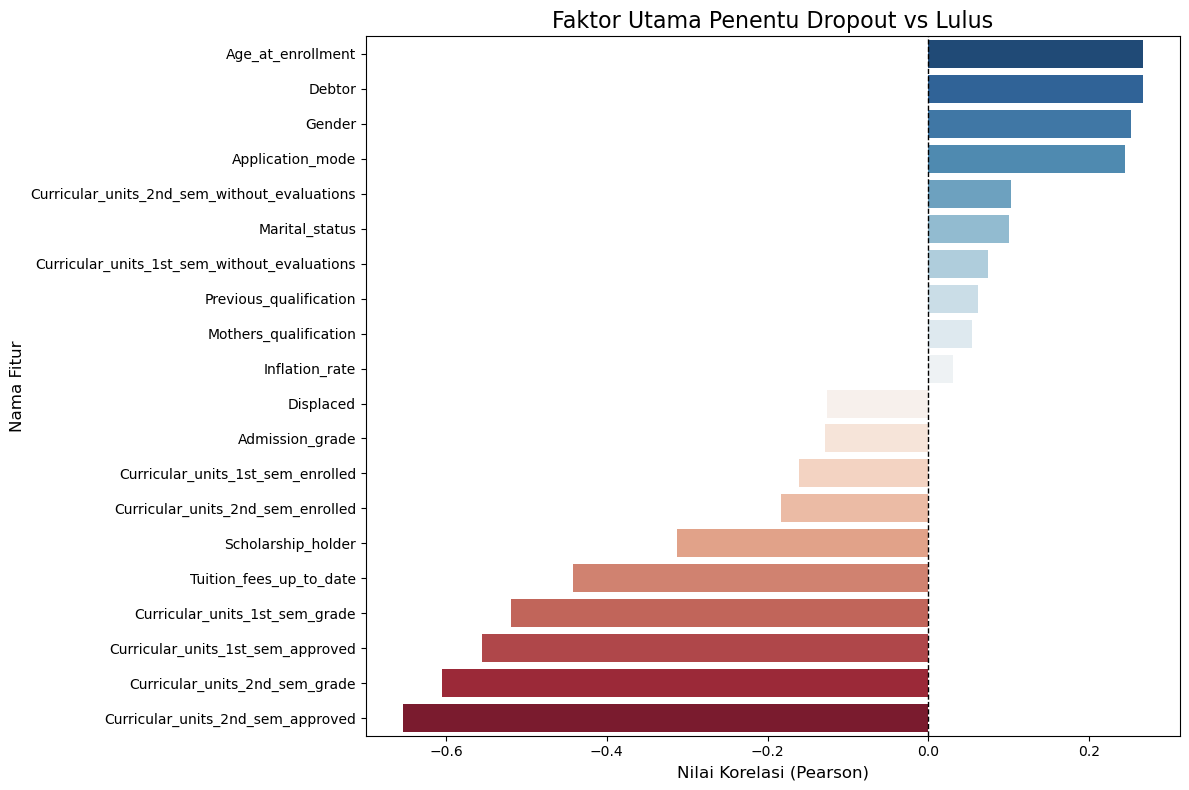

Top 5 Faktor Pendorong Dropout:
Age_at_enrollment                               0.267229
Debtor                                          0.267207
Gender                                          0.251955
Application_mode                                0.244507
Curricular_units_2nd_sem_without_evaluations    0.102687
Name: Status, dtype: float64

Top 5 Faktor Pendorong Kelulusan:
Curricular_units_2nd_sem_approved   -0.653995
Curricular_units_2nd_sem_grade      -0.605350
Curricular_units_1st_sem_approved   -0.554881
Curricular_units_1st_sem_grade      -0.519927
Tuition_fees_up_to_date             -0.442138
Name: Status, dtype: float64


In [3]:
df_clean = df.copy()

df_clean = df_clean[df_clean['Status'] != 'Enrolled']
df_clean['Status'] = df_clean['Status'].map({'Dropout': 1, 'Graduate': 0})
print("Distribusi Status setelah dibersihkan:")
print(df_clean['Status'].value_counts())
print("\nRasio Kelas (%):")
print(df_clean['Status'].value_counts(normalize=True) * 100)

correlation = df_clean.corr()['Status'].sort_values(ascending=False)
correlation = correlation.drop('Status')

top_positive = correlation.head(10)
top_negative = correlation.tail(10)
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='RdBu_r')
plt.title('Faktor Utama Penentu Dropout vs Lulus', fontsize=16)
plt.xlabel('Nilai Korelasi (Pearson)', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

print("Top 5 Faktor Pendorong Dropout:")
print(top_positive.head(5))
print("\nTop 5 Faktor Pendorong Kelulusan:")
print(top_negative.sort_values().head(5))

df_clean.to_csv("data/cleaned_student_data.csv", index=False)

## Modeling

In [4]:
X = df_clean.drop('Status', axis=1)
y = df_clean['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print("\n✅ Model Random Forest berhasil dilatih!")
os.makedirs('model', exist_ok=True)
joblib.dump(rf_model, 'model/rf_model.joblib')
print("✅ Model berhasil disimpan di direktori 'model/rf_model.joblib'")

Jumlah data training: 2904
Jumlah data testing: 726

✅ Model Random Forest berhasil dilatih!
✅ Model berhasil disimpan di direktori 'model/rf_model.joblib'


## Evaluation

--- Laporan Evaluasi Model ---
Accuracy Score: 92.84%

Classification Report:
              precision    recall  f1-score   support

Graduate (0)       0.92      0.96      0.94       442
 Dropout (1)       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



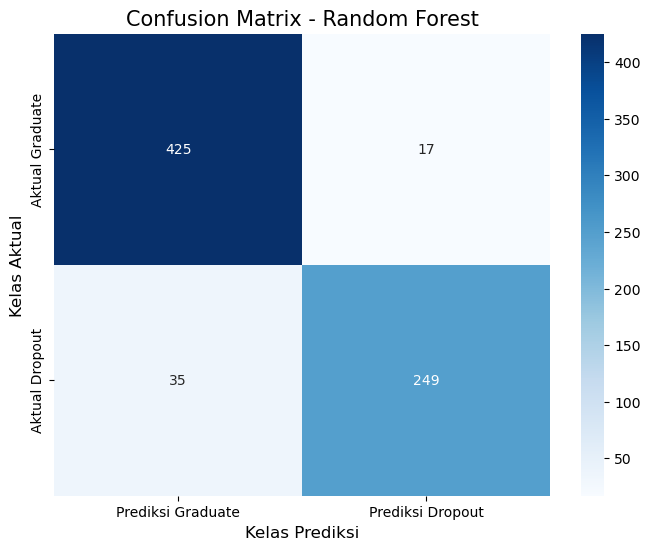

In [5]:
y_pred = rf_model.predict(X_test)
print("--- Laporan Evaluasi Model ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Graduate', 'Prediksi Dropout'],
            yticklabels=['Aktual Graduate', 'Aktual Dropout'])
plt.title('Confusion Matrix - Random Forest', fontsize=15)
plt.ylabel('Kelas Aktual', fontsize=12)
plt.xlabel('Kelas Prediksi', fontsize=12)
plt.show()